In [3]:
#setting up the notebook
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [4]:
#reading the csv file
df= pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/medicaldataset.csv')

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X=df.drop('Result', axis=1)
X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

Text(0.5, 1.0, 't-SNE plot')

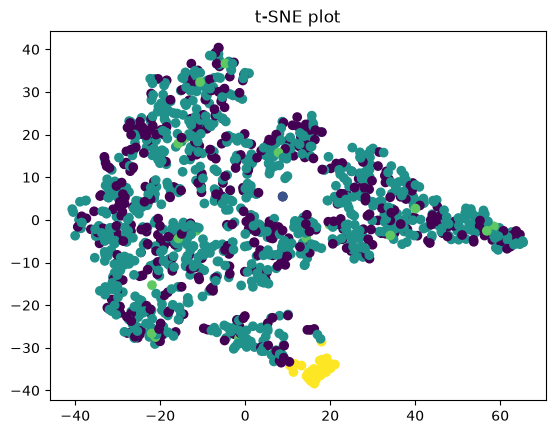

In [6]:
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)
plt.title("t-SNE plot")

PCA shows the overall spread and hints at which clusters might be outliers, but its heavy overlap makes it hard to trust the cluster boundaries.
t-SNE resolves that ambiguity for yellow — proving it's a real, separable cluster despite looking unclear in PCA — while confirming that purple and teal are likely not genuinely separate groups, since even t-SNE's local-neighborhood preservation can't pull them apart.

In [ ]:
#flagging the anomalies
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(X_scaled)
# -1 = anomaly, 1 = normal
print(pd.Series(preds).value_counts())

 1    1253
-1      66
Name: count, dtype: int64


There are 66 anomalies flagged 

In [14]:
df['preds'] = preds  
anomalies= df[df['preds']==-1]
print(anomalies.head())


    Age  Gender  Heart rate  Systolic blood pressure  \
1    21       1          94                       98   
7    63       1          60                      214   
12   64       1          60                      199   
28   47       0          66                      134   
29   63       1          66                      135   

    Diastolic blood pressure  Blood sugar    CK-MB  Troponin    Result  preds  
1                         46        296.0    6.750     1.060  positive     -1  
7                         82         87.0  300.000     2.370  positive     -1  
12                        99         92.0    3.430     5.370  positive     -1  
28                        57        279.0  300.000     0.007  positive     -1  
29                        55        166.0    0.493    10.000  negative     -1  


In [16]:
normal_avg = df[df['preds'] == 1].mean(numeric_only=True)
print(normal_avg)


Age                          55.970471
Gender                        0.666401
Heart rate                   76.646449
Systolic blood pressure     126.335196
Diastolic blood pressure     72.142059
Blood sugar                 144.560814
CK-MB                         9.623105
Troponin                      0.244874
preds                         1.000000
dtype: float64


In [ ]:
point_1 = anomalies.iloc[0]
print(point_1)


Age                               21
Gender                             1
Heart rate                        94
Systolic blood pressure           98
Diastolic blood pressure          46
Blood sugar                    296.0
CK-MB                           6.75
Troponin                        1.06
Result                      positive
preds                             -1
Name: 1, dtype: object


In [19]:
point_2 = anomalies.iloc[1]
print(point_2)

Age                               63
Gender                             1
Heart rate                        60
Systolic blood pressure          214
Diastolic blood pressure          82
Blood sugar                     87.0
CK-MB                          300.0
Troponin                        2.37
Result                      positive
preds                             -1
Name: 7, dtype: object


### Anomaly Inspection

**Point 1 (index 1):**
- Age = 21 vs. normal average = 56 — unusually young for this dataset.
- Blood sugar = 296 vs. normal average = 144.6 — roughly double the typical value.
- Troponin = 1.06 vs. normal average = 0.24 — about 4x higher, a key marker of heart damage.
- Diastolic BP = 46 vs. normal average = 72.1 — notably low.
- Hypothesis: This point was flagged mainly because it's a rare combination — 
  a young patient with abnormally high troponin and blood sugar and low blood 
  pressure.

**Point 2 (index 7):**
- CK-MB = 300 vs. normal average = 9.6 — about 31x higher, an extreme spike.
- Troponin = 2.37 vs. normal average = 0.24 — nearly 10x higher.
- Systolic BP = 214 vs. normal average = 126.3 — far above typical range 
  (hypertensive crisis territory).
- Hypothesis: Unlike Point 1, this point doesn't need a rare combination to 
  stand out — CK-MB and troponin are both extreme outliers on their own. 
  These are classic biomarkers of a severe cardiac event (e.g., heart 
  attack), so this point was likely isolated almost immediately since a 
  single random split on CK-MB or troponin would separate it from the rest 
  of the dense "normal" population.


In [20]:
anomalies['Result'].value_counts()

Result
positive    63
negative     3
Name: count, dtype: int64